In [4]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

import matplotlib.pyplot as plt


In [5]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["Species"] = iris.target


In [6]:
species_names = {
    0:"Setosa",
    1:"Versicolor",
    2:"Virginica"
}

df["Species"] = df["Species"].map(species_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [7]:
sizes = [
    "Small",
    "Medium",
    "Large"
]

np.random.seed(10)

df["Plant_Size"] = np.random.choice(sizes, len(df))

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species,Plant_Size
0,5.1,3.5,1.4,0.2,Setosa,Medium
1,4.9,3.0,1.4,0.2,Setosa,Medium
2,4.7,3.2,1.3,0.2,Setosa,Small
3,4.6,3.1,1.5,0.2,Setosa,Small
4,5.0,3.6,1.4,0.2,Setosa,Medium


In [8]:
label = LabelEncoder()

df["Species_Label"] = label.fit_transform(df["Species"])

df[["Species","Species_Label"]].head()

,Species,Species_Label
0,Setosa,0
1,Setosa,0
2,Setosa,0
3,Setosa,0
4,Setosa,0


In [9]:
encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df[["Species"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["Species"])
)

encoded_df.head()

,Species_Setosa,Species_Versicolor,Species_Virginica
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


In [10]:
ordinal = OrdinalEncoder(
    categories=[["Small","Medium","Large"]]
)

df["Plant_Size_Encoded"] = ordinal.fit_transform(
    df[["Plant_Size"]]
)

df[["Plant_Size","Plant_Size_Encoded"]].head()

,Plant_Size,Plant_Size_Encoded
0,Medium,1.0
1,Medium,1.0
2,Small,0.0
3,Small,0.0
4,Medium,1.0


In [11]:
standard = StandardScaler()

standard_scaled = standard.fit_transform(
    iris.data
)

standard_df = pd.DataFrame(
    standard_scaled,
    columns=iris.feature_names
)

standard_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [12]:
minmax = MinMaxScaler()

minmax_scaled = minmax.fit_transform(
    iris.data
)

minmax_df = pd.DataFrame(
    minmax_scaled,
    columns=iris.feature_names
)

minmax_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


In [13]:
robust = RobustScaler()

robust_scaled = robust.fit_transform(
    iris.data
)

robust_df = pd.DataFrame(
    robust_scaled,
    columns=iris.feature_names
)

robust_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.538462,1.0,-0.842857,-0.733333
1,-0.692308,0.0,-0.842857,-0.733333
2,-0.846154,0.4,-0.871429,-0.733333
3,-0.923077,0.2,-0.814286,-0.733333
4,-0.615385,1.2,-0.842857,-0.733333


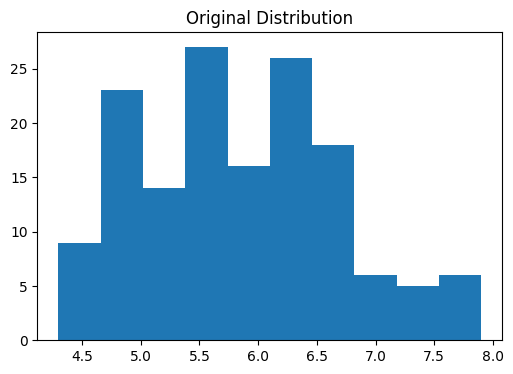

In [14]:
plt.figure(figsize=(6,4))
plt.hist(df["sepal length (cm)"])
plt.title("Original Distribution")
plt.show()

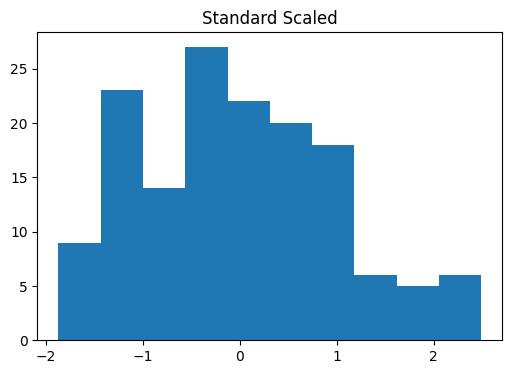

In [15]:
plt.figure(figsize=(6,4))
plt.hist(standard_df["sepal length (cm)"])
plt.title("Standard Scaled")
plt.show()

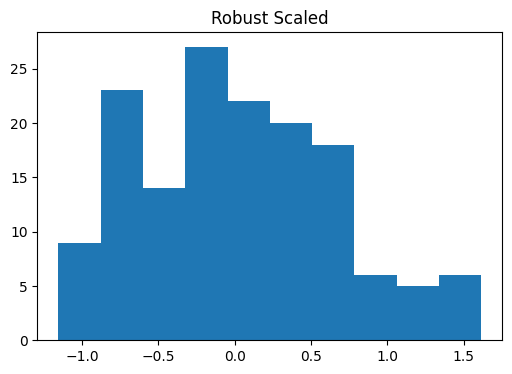

In [16]:
plt.figure(figsize=(6,4))
plt.hist(robust_df["sepal length (cm)"])
plt.title("Robust Scaled")
plt.show()

In [17]:
X = iris.data
y = iris.target

In [18]:
selector = SelectKBest(
    score_func=f_classif,
    k="all"
)

selector.fit(X,y)

scores = pd.DataFrame({
    "Feature":iris.feature_names,
    "Score":selector.scores_
})

scores.sort_values(
    by="Score",
    ascending=False
)

,Feature,Score
2,petal length (cm),1180.161182
3,petal width (cm),960.007147
0,sepal length (cm),119.264502
1,sepal width (cm),49.160040


In [19]:
selector = SelectKBest(score_func=f_classif, k=4)